In [17]:
%load_ext autoreload
%autoreload 2
from models import *
from utilsSimpleConv2D import *
from fetch_data import *
import tensorflow_datasets as tfds


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
x_train, y_train,x_test, y_test=generate_data(name_data='mnist1d')

In [3]:
# Charger le dataset "imagenette" en taille 320px
dataset, info = tfds.load(
    'imagenette/320px',
    split='train',
    with_info=True,
    as_supervised=True  # retourne (image, label)
)

# Aperçu des classes
print("Classes :", info.features['label'].names)


c:\Users\jketchak\Documents\DALPHAcommunity\UNAMUR\EUREKA\btwg_ml\SpectralConvxD\Code\mon_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [04:54<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [04:55<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [04:56<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [04:57<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [04:58<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [04:59<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [05:00<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [05:01<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [05:02<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [05:03<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [05:04<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [05:05<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [05:06<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/1 [05:07<00:00, 69.28s/ url]

Dl Completed...: 100%|██████████| 1/

Dataset imagenette downloaded and prepared to C:\Users\jketchak\tensorflow_datasets\imagenette\320px\1.0.0. Subsequent calls will reuse this data.
Classes : ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


(320, 396, 3)


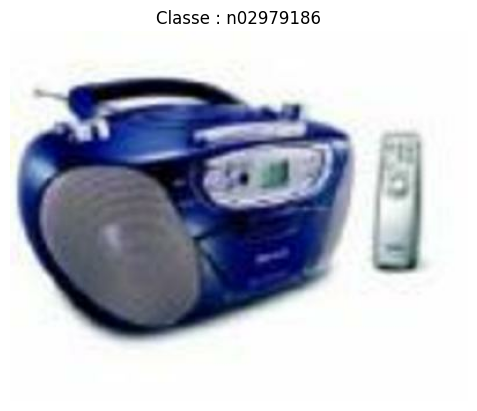

(320, 426, 3)


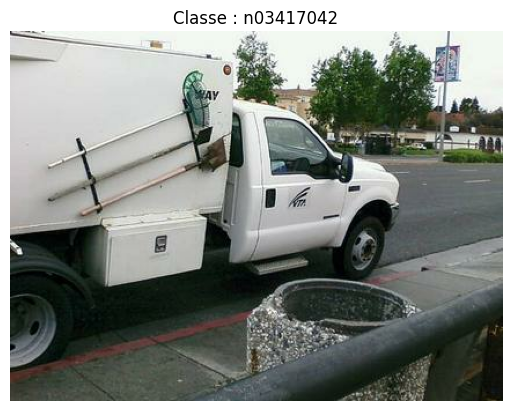

(320, 477, 3)


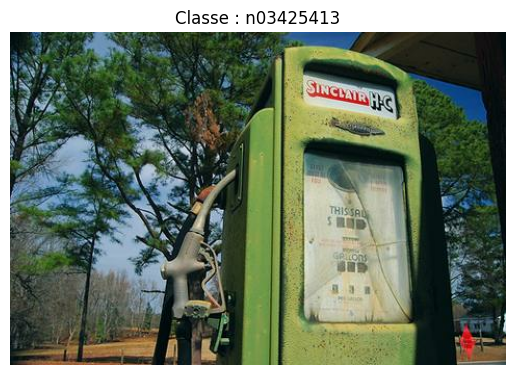

In [18]:
for image, label in dataset.take(3):
    print(image.shape)
    plt.imshow(image.numpy())
    plt.title(f"Classe : {info.features['label'].names[label.numpy()]}")
    plt.axis('off')
    plt.savefig(f'{label}.pdf')
    plt.show()

In [299]:
spectral_config = {  'is_base_trainable': True,
                     'is_diag_start_trainable': False,
                     'is_diag_end_trainable': False,
                     'use_bias': True
                    }

spectral_cnn1d_config ={ 'kernel_size': 3,
                         'stride': 1,
                         'padding': 0,
                         'trainable_phi':False,
                         'use_lambda_out':False,
                         'use_lambda_in' : True,
                         'use_bias': True}

spectral_cnn2d_config={ 'kernel_size': 3,
                        'strides': 1,
                        'padding': 'VALID',
                        "use_lambda_out":False,
                        "use_lambda_in":False,
                        "use_encode":False,
                        "use_decode":False,
                        'use_bias': False,
                        "trainable_omega_diag":True,
                        "trainable_omega_triu":True,
                        "trainable_omega_tril":True,
                        "trainable_aggregate":True,
                        "kernel_initializer":"glorot_uniform"
                        }

maxpooling_config ={ 'pool_size': 3,
                     'strides': 1,
                     'padding': 'same' }

hyperparameters = { 'filters' :20,
                    'input_shape' :(40,),
                    'learning_rate' : 0.03,
                    'epochs' : 20,
                    'batch_size' :100,
                    'activation': 'relu',
                    'labels' : 10}





In [300]:
models = SpectralCnn(spectral_config=spectral_config,
                     spectral_cnn1d_config=spectral_cnn1d_config,
                     spectral_cnn2d_config=spectral_cnn2d_config,
                     hyperparameters=hyperparameters,
                     maxpooling_config=maxpooling_config)

In [301]:
print("build model")
models.compile_models(units=3000, Use_pruning=False,pruning=0.1, use_base_and_Lambda=True, name='Dspec')
models.summary(name='Dspec')


build model
Dspec model compilation
Dspec model summary:
 


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spec_cnn1d_32 (SpecCnn1d)       │ (None, 38, 20)         │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_31 (MaxPooling1D) │ (None, 38, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_31 (Flatten)            │ (None, 760)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_39 (Spectral)          │ (None, 3000)           │     2,286,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_40 (Spectral)          │ (None, 10)             │        30,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,316,100 (8.84 MB)

 Trainable params: 2,316,100 (8.84 MB)

 Non-trainable params: 0 (0.00 B)

In [302]:
models.train(x_train, y_train, x_test, y_test, name='Dspec',verbose=1,layers=(3,4))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2840 - loss: 3.0349 - val_accuracy: 0.7420 - val_loss: 0.7320
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7977 - loss: 0.6174 - val_accuracy: 0.8360 - val_loss: 0.5354
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8827 - loss: 0.3799 - val_accuracy: 0.8865 - val_loss: 0.3443
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9189 - loss: 0.2700 - val_accuracy: 0.9200 - val_loss: 0.2657
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9475 - loss: 0.1869 - val_accuracy: 0.9215 - val_loss: 0.2996
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9547 - loss: 0.1679 - val_accuracy: 0.9095 - val_loss: 0.3225
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9490 - loss: 0.1641 - val_accuracy: 0.9295 - val_loss: 0.2373
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9729 - loss: 0.1166 - val_accuracy: 0.9230 - v

In [286]:
p=[0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,1]

In [304]:
accuracy=[models.evaluate(x_test, y_test, order=0, name='Dspec',layers=[3],p=val) for val in p]

[ 1.7961485e-35  4.3896515e-35 -4.2545594e-02 ... -5.8112931e-02
 -7.1320393e-36 -7.1427403e-36]
3000
[[ 1.7961485e-35  4.3896515e-35 -4.2545594e-02 ... -5.8112931e-02
  -7.1320393e-36 -7.1427403e-36]]
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9434 - loss: 0.2739
[ 1.7961485e-35  4.3896515e-35 -4.2545594e-02 ... -5.8112931e-02
 -7.1320393e-36 -7.1427403e-36]
3000
[[ 1.7961485e-35  4.3896515e-35 -4.2545594e-02 ... -5.8112931e-02
  -7.1320393e-36 -7.1427403e-36]]
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7558 - loss: 0.7719
[ 1.7961485e-35  4.3896515e-35  0.0000000e+00 ...  0.0000000e+00
 -7.1320393e-36 -7.1427403e-36]
3000
[[ 1.7961485e-35  4.3896515e-35  0.0000000e+00 ...  0.0000000e+00
  -7.1320393e-36 -7.1427403e-36]]
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7558 - loss: 0.7719
[ 1.7961485e-35  4.3896515e-35  0.0000000e+00 ...  0.0000000e+00
 -7.1320393e-36 -7.1427403e-36]
3000
[[ 1.7961485e-35  4.3896515e-35  0.0000000e+00 ...  0.0000000e+00
  -7.13

In [ ]:
accuracy1 

[0.9125000238418579,
 0.9125000238418579,
 0.9139999747276306,
 0.9144999980926514,
 0.9175000190734863,
 0.9039999842643738,
 0.8579999804496765,
 0.8395000100135803,
 0.7580000162124634,
 0.5540000200271606,
 0.3869999945163727,
 0.3050000071525574,
 0.1054999977350235]

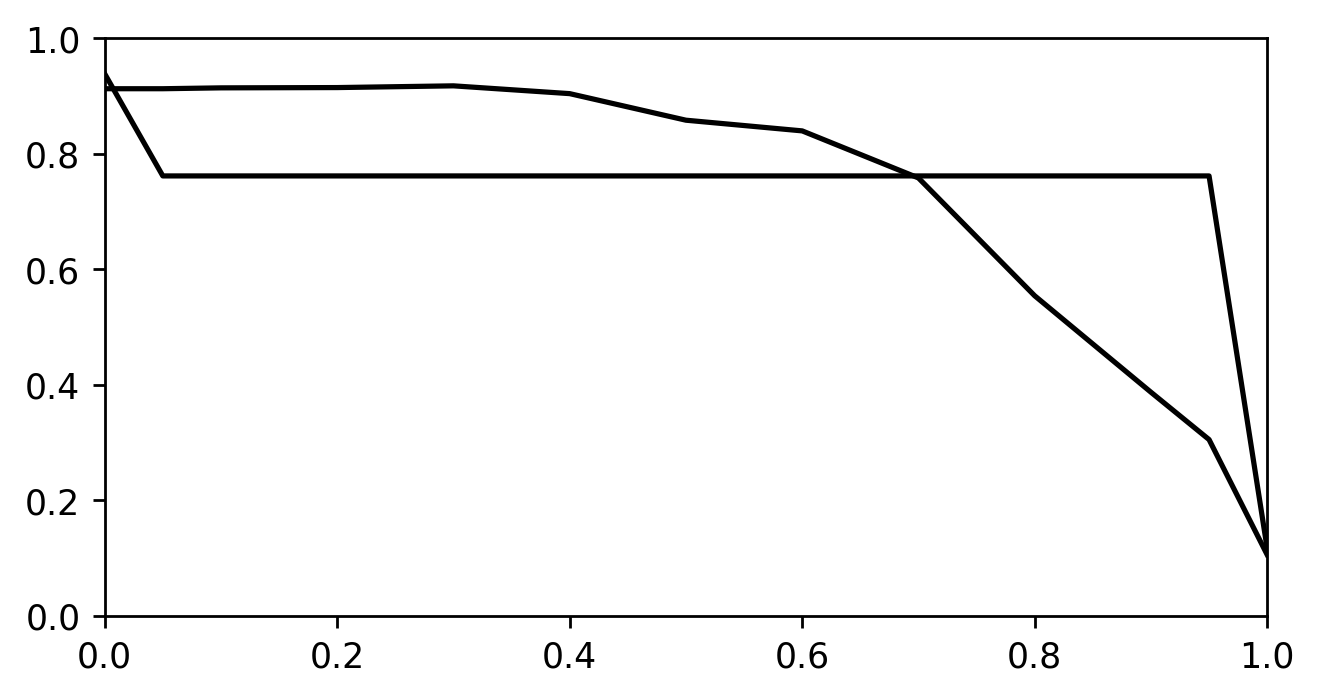

In [305]:
fig, ax = plt.subplots(num=1,figsize=(6,3),dpi=250)
ax.axis([0, 1, 0, 1])
plt.plot(p,accuracy,color='k')
plt.plot(p,accuracy1,color='k')



In [223]:
def absolute_value_of_the_incoming_connectivity_collapse(matrix, p_percent):
    """
    Calculates the sum of absolute values of weights for each row, orders them,
    and sets to zero the p percent lowest values (weakest connections).
    
    Args:
        matrix (list or np.array): Input matrix
        p_percent (float): Percentage of weakest rows to collapse (0.0-1.0)
    
    Returns:
        tuple: (filtered_matrix, collapsed_indices, row_sums, threshold_value)
            - filtered_matrix (np.array): Matrix with weakest rows set to zero
            - collapsed_indices (np.array): Indices of rows that were collapsed
            - row_sums (np.array): Array of absolute row sums before collapse
            - threshold_value (float): The threshold value used for collapse
    """
    # Validate percentage
    if not isinstance(p_percent, (int, float)):
        raise TypeError("p_percent must be a number")
    if not (0 <= p_percent <= 1):
        raise ValueError("p_percent must be between 0 and 1")
    
    # Convert to numpy array if not already
    mat = np.array(matrix)
    
    if mat.size == 0:
        return mat, np.array([]), np.array([]), 0.0
    
    # Create a copy to avoid modifying the original
    result = mat.copy()
    
    # Calculate sum of absolute values for each row
    row_sums = np.sum(np.abs(mat), axis=1)
    
    # Calculate how many rows to collapse
    num_rows = mat.shape[0]
    num_to_collapse = int(np.ceil(num_rows * p_percent))
    
    if num_to_collapse == 0:
        # No rows to collapse
        return result, np.array([]), row_sums, 0.0
    
    # Find indices of rows with smallest sums (weakest connections)
    sorted_indices = np.argsort(row_sums)
    collapsed_indices = sorted_indices[:num_to_collapse]
    
    # Determine threshold value
    if num_to_collapse < num_rows:
        threshold_value = row_sums[sorted_indices[num_to_collapse - 1]]
    else:
        threshold_value = row_sums[sorted_indices[-1]]
    
    # Set the weakest rows to zero
    result[collapsed_indices, :] = 0
    
    return result, collapsed_indices, row_sums, threshold_value


In [227]:
matrix1 = np.array([
    [0.1, -0.2, 0.3],      # sum = 0.6
    [1.5, 2.0, -0.5],      # sum = 4.0
    [0.05, 0.1, -0.05],    # sum = 0.2
    [3.0, -1.0, 2.5],      # sum = 6.5
    [0.2, -0.1, 0.15],     # sum = 0.45
    [0.8, 0.6, -0.4]       # sum = 1.8
])

print("Original matrix:")
print(np.array(matrix1))

# Test with 0.33 collapse (should collapse 2 weakest rows)
p_percent = 0.33
print(f"\nCollapsing {p_percent:.0%} of weakest rows:")

result1, collapsed_idx1, sums1, threshold1 = absolute_value_of_the_incoming_connectivity_collapse(matrix1, p_percent)

print(f"Row sums (absolute values): {sums1}")
print(f"Collapsed row indices: {collapsed_idx1}")
print(f"Threshold value: {threshold1}")
print(f"Number of rows collapsed: {len(collapsed_idx1)}")
print("Matrix after collapse:")
print(result1)
print()

Original matrix:
[[ 0.1  -0.2   0.3 ]
 [ 1.5   2.   -0.5 ]
 [ 0.05  0.1  -0.05]
 [ 3.   -1.    2.5 ]
 [ 0.2  -0.1   0.15]
 [ 0.8   0.6  -0.4 ]]

Collapsing 33% of weakest rows:
Row sums (absolute values): [0.6  4.   0.2  6.5  0.45 1.8 ]
Collapsed row indices: [2 4]
Threshold value: 0.45000000000000007
Number of rows collapsed: 2
Matrix after collapse:
[[ 0.1 -0.2  0.3]
 [ 1.5  2.  -0.5]
 [ 0.   0.   0. ]
 [ 3.  -1.   2.5]
 [ 0.   0.   0. ]
 [ 0.8  0.6 -0.4]]



In [228]:
matrix1.size

18

In [221]:
def quantile_robust(array, p):
    """
    Calcule le quantile d'ordre p avec gestion d'erreurs
    
    Parameters:
    array : array-like
        Le vecteur de données
    p : float
        L'ordre du quantile (entre 0 et 1)
        
    Returns:
    float : Le quantile d'ordre p
    
    Raises:
    ValueError : Si p n'est pas entre 0 et 1
    """
    if not 0 <= p <= 1:
        raise ValueError("p doit être entre 0 et 1")
    
    array = np.asarray(array)
    
    if array.size == 0:
        raise ValueError("Le vecteur ne peut pas être vide")
    
    # Enlever les valeurs NaN
    array_clean = array[~np.isnan(array)]
    
    if array_clean.size == 0:
        raise ValueError("Le vecteur ne contient que des valeurs NaN")
    
    return np.quantile(array_clean, p)

In [172]:
data_with_nan = np.array([1, 2, np.nan, 4, 5, 6, 7, 8, 9, 10])
print(f"Quantile 0.5: {quantile_robust(data_with_nan, 0.5)}")

Quantile 0.5: 6.0


In [165]:
def threshold_filter(threshold, vector):
    """
    Sets to zero the values in the vector that are smaller than the threshold.
    
    Args:
        threshold (float): Threshold value
        vector (list or np.array): Input vector
    
    Returns:
        tuple: (filtered_vector, percentage_zeroed)
            - filtered_vector (np.array): Vector with values < threshold set to zero
            - percentage_zeroed (float): Percentage of values that were set to zero
    """
    # Convert to numpy array if not already
    vec = np.array(vector)
    
    # Create a copy to avoid modifying the original
    result = vec.copy()
    
    # Count values below threshold
    values_below_threshold = np.sum(vec < threshold)
    total_values = len(vec)
    
    # Calculate percentage
    percentage_zeroed = (values_below_threshold / total_values) * 100 if total_values > 0 else 0
    
    # Set values below threshold to zero
    result[result < threshold] = 0
    
    return result, percentage_zeroed

In [170]:
vector1 = [1, 5, 3, 8, 2, 9, 4]
threshold1 = quantile_robust(vector1, p=1)

print(f"Original vector: {vector1}")
print(f"Threshold: {threshold1}")
result1 = threshold_filter(threshold1, vector1)
print(f"Result: {result1}")
print()

Original vector: [1, 5, 3, 8, 2, 9, 4]
Threshold: 9
Result: (array([0, 0, 0, 0, 0, 9, 0]), np.float64(85.71428571428571))

